# REGRESIÓN LOGÍSTICA
## Predicción de acceso a Internet en el departamento de La Paz

### 1. Introducción

El objetivo es estimar la probabilidad de que una vivienda u hogar del departamento de La Paz tenga acceso a Internet usando características censales. La fuente son los microdatos de Vivienda y el diccionario oficial del Censo de Población y Vivienda 2024.

La Regresión Logística es adecuada porque el resultado es una **clasificación binaria**: cada registro válido pertenece a una de dos clases, tiene acceso (`1`) o no tiene acceso (`0`). Esta es una primera iteración interpretable; sus asociaciones no se interpretan como relaciones causales.

### 2. Librerías

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

RAIZ = Path.cwd().resolve()
if RAIZ.name == 'notebooks':
    RAIZ = RAIZ.parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.logistic_regression import (
    ejecutar_entrenamiento, preparar_dataset_modelo, resultado_serializable,
    TARGET, TARGET_SOURCE, MODEL_FEATURES
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

### 3. Carga de datos

Se reutiliza `src.logistic_regression`, que a su vez aprovecha la lectura en bloques y el subconjunto departamental reproducible de `src.pipeline`. La fuente original permanece en `Base de datos CSV/` y no se modifica.

In [2]:
datos_modelo = preparar_dataset_modelo(RAIZ, prefer_cache=True)
auditoria = datos_modelo.audit
pd.Series({
    'Registros de La Paz': auditoria['registros_lapaz'],
    'Universo TIC': auditoria['universo_tic'],
    'Target válido': auditoria['registros_target_valido'],
    'Registros excluidos': auditoria['registros_excluidos'],
}, name='Cantidad').to_frame()

,Cantidad
Registros de La Paz,1334496
Universo TIC,1069838
Target válido,1039341
Registros excluidos,295155


### 4. Identificación de la métrica

In [3]:
conteos = datos_modelo.y.value_counts().sort_index()
total_valido = int(conteos.sum())
metrica_principal = pd.DataFrame({
    'Resultado': ['Sin Internet', 'Con Internet'],
    'Cantidad': [int(conteos[0]), int(conteos[1])],
    'Porcentaje': [conteos[0] / total_valido * 100, conteos[1] / total_valido * 100],
})
display(Markdown('**Métrica principal:** acceso a Internet fijo y/o móvil.'))
metrica_principal

**Métrica principal:** acceso a Internet fijo y/o móvil.

,Resultado,Cantidad,Porcentaje
0,Sin Internet,290940,27.992738
1,Con Internet,748401,72.007262


### 5. Definición del target

El diccionario oficial identifica `v19e_f` como **Internet fijo en la vivienda o Internet móvil**. Se crea `TIENE_ACCESO_INTERNET` con `1 = Sí` y `0 = No`. El código `9 = Sin especificar`, los vacíos y valores fuera de catálogo no se convierten en No.

**Las variables de Internet fijo y móvil no se utilizan como predictores para evitar fuga de información (data leakage).**

,cantidad
TIENE_ACCESO_INTERNET,
1,748401
0,290940


,proporción
TIENE_ACCESO_INTERNET,
1,0.720073
0,0.279927


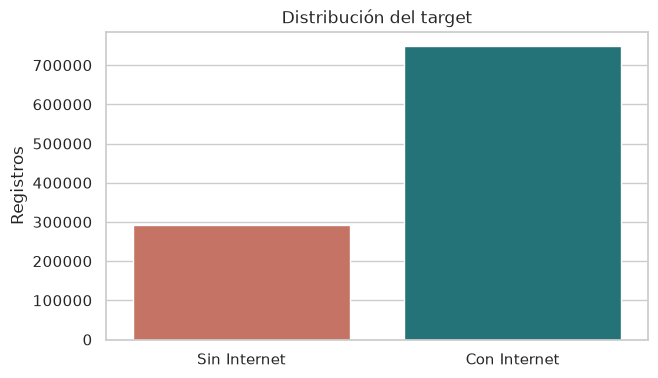

La clase positiva representa **72.01%** de los registros válidos. Existe desbalance, por lo que se evaluarán precision, recall, F1 y ROC-AUC además de accuracy.

In [4]:
display(datos_modelo.y.value_counts().rename('cantidad').to_frame())
display(datos_modelo.y.value_counts(normalize=True).rename('proporción').to_frame())

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=metrica_principal, x='Resultado', y='Cantidad', hue='Resultado', legend=False, ax=ax, palette=['#d56855', '#167f87'])
ax.set_title('Distribución del target')
ax.set_xlabel('')
ax.set_ylabel('Registros')
plt.show()

display(Markdown(f"La clase positiva representa **{datos_modelo.y.mean():.2%}** de los registros válidos. Existe desbalance, por lo que se evaluarán precision, recall, F1 y ROC-AUC además de accuracy."))

### 6. Variables explicativas

In [5]:
pd.DataFrame(auditoria['variables']).rename(columns={'variable': 'Variable', 'descripcion': 'Descripción', 'tipo': 'Tipo', 'motivo': 'Motivo para incluirla'})

,Variable,Descripción,Tipo,Motivo para incluirla
0,urbrur,Área Urbana - Rural,Categórica,La disponibilidad de infraestructura y cobertura digital puede diferir entre áreas urbanas y rurales.
1,v01_tipoviv,1. La vivienda es: (Tipo de vivienda),Categórica,El tipo de vivienda aproxima condiciones residenciales asociadas con la posibilidad de contratar o instalar conectiv...
2,v09_energia,9. De donde proviene la energía eléctrica que usan en la vivienda,Categórica,La fuente de energía eléctrica representa una condición básica para usar equipos y servicios digitales.
3,v19c_compu,"19.3. Su hogar tiene: Computadora, laptop o tablet",Categórica,"La disponibilidad de computadora, laptop o tablet está asociada con la capacidad de uso de servicios digitales, sin ..."
4,v19d_celular,19.4. Su hogar tiene: Teléfono celular,Categórica,"La tenencia de teléfono celular está asociada con la posibilidad de usar servicios digitales, pero no equivale a dec..."
5,v13_habitac,"13. Cuántos cuartos o habitaciones ocupan, sin contar baño y cocina",Numérica,La cantidad de habitaciones describe el tamaño físico de la vivienda y puede aproximar diferencias socioeconómicas.
6,tot_pers,Total personas,Numérica,El tamaño del hogar puede relacionarse con la demanda compartida y la capacidad de sostener un servicio de Internet.


No se incluyen códigos de departamento, provincia, municipio ni identificadores. Tampoco se incluyen `v19e_inetfijo`, `v19f_inetmovil` o `v19e_f`, porque revelarían directa o parcialmente la respuesta.

### 7. Preparación de datos

In [6]:
X = datos_modelo.X
y = datos_modelo.y
display(X.head())
display(pd.DataFrame({
    'Variable': X.columns,
    'Faltantes antes de imputar': [int(X[columna].isna().sum()) for columna in X.columns],
}))
print('Target únicamente 0/1:', sorted(y.unique().tolist()))

,urbrur,v01_tipoviv,v09_energia,v19c_compu,v19d_celular,v13_habitac,tot_pers
222,2,1,1,2,1,4,4
414,1,1,1,2,1,1,4
419,2,1,1,1,1,6,3
425,2,1,1,1,2,5,7
967,1,1,1,1,1,4,7


,Variable,Faltantes antes de imputar
0,urbrur,0
1,v01_tipoviv,0
2,v09_energia,0
3,v19c_compu,49
4,v19d_celular,80
5,v13_habitac,0
6,tot_pers,0


Target únicamente 0/1: [0, 1]


Las variables categóricas se imputan con la moda y se transforman mediante one-hot encoding, eliminando una categoría de referencia. Las numéricas se imputan con la mediana. Los códigos categóricos no se interpretan como cantidades.

### 8. Partición Train / Test

Se usa 80 % para entrenamiento y 20 % para prueba con `random_state=777` y `stratify=y`. El conjunto de prueba queda reservado para evaluar datos nunca vistos.

### 9. Modelo base

La primera iteración usa `LogisticRegression(max_iter=1000)` sin `class_weight` y sin SMOTE, para observar el comportamiento natural del modelo.

### 10. Entrenamiento

In [7]:
resultados = ejecutar_entrenamiento(RAIZ, prefer_cache=True, save_outputs=False)
resumen = resultado_serializable(resultados)
ejecucion = resultados['_runtime']

print('X_train:', ejecucion['X_train'].shape)
print('X_test:', ejecucion['X_test'].shape)
display(ejecucion['y_train'].value_counts().sort_index().rename('train').to_frame())
display(ejecucion['y_test'].value_counts().sort_index().rename('test').to_frame())

X_train: (831472, 7)
X_test: (207869, 7)


,train
TIENE_ACCESO_INTERNET,
0,232752
1,598720


,test
TIENE_ACCESO_INTERNET,
0,58188
1,149681


El pipeline se ajusta exclusivamente con `X_train` y `y_train`. `X_test` no participa en la imputación, el one-hot encoding ni el entrenamiento.

### 11. Evaluación TRAIN

,Train
accuracy,0.803081
precision,0.814012
recall,0.941687
f1,0.873208
roc_auc,0.862268


TN=103,932 · FP=128,820 · FN=34,913 · TP=563,807


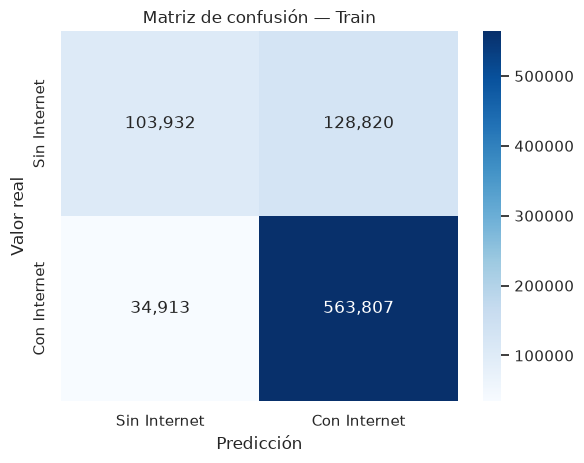

In [8]:
metricas_train = pd.Series(resumen['metricas']['train'], name='Train').to_frame()
display(metricas_train)
pred_train = ejecucion['pipeline'].predict(ejecucion['X_train'])
matriz_train = confusion_matrix(ejecucion['y_train'], pred_train, labels=[0, 1])
tn_train, fp_train, fn_train, tp_train = matriz_train.ravel()
print(f'TN={tn_train:,} · FP={fp_train:,} · FN={fn_train:,} · TP={tp_train:,}')
sns.heatmap(matriz_train, annot=True, fmt=',d', cmap='Blues', xticklabels=['Sin Internet', 'Con Internet'], yticklabels=['Sin Internet', 'Con Internet'])
plt.title('Matriz de confusión — Train')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

### 12. Evaluación TEST

,Test
accuracy,0.803444
precision,0.814425
recall,0.941582
f1,0.873400
roc_auc,0.862540


TN=26,074 · FP=32,114 · FN=8,744 · TP=140,937
              precision    recall  f1-score   support

Sin Internet       0.75      0.45      0.56     58188
Con Internet       0.81      0.94      0.87    149681

    accuracy                           0.80    207869
   macro avg       0.78      0.69      0.72    207869
weighted avg       0.80      0.80      0.79    207869



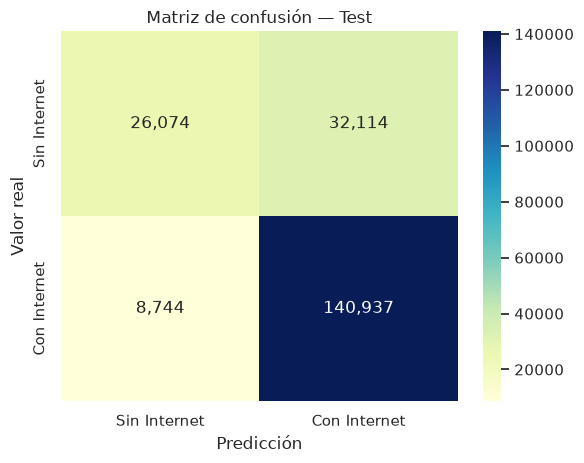

In [9]:
metricas_test = pd.Series(resumen['metricas']['test'], name='Test').to_frame()
display(metricas_test)
matriz_test = np.array(resumen['matriz_confusion_test']['matriz'])
tn, fp, fn, tp = matriz_test.ravel()
print(f'TN={tn:,} · FP={fp:,} · FN={fn:,} · TP={tp:,}')
pred_test = ejecucion['pipeline'].predict(ejecucion['X_test'])
print(classification_report(ejecucion['y_test'], pred_test, target_names=['Sin Internet', 'Con Internet'], zero_division=0))
sns.heatmap(matriz_test, annot=True, fmt=',d', cmap='YlGnBu', xticklabels=['Sin Internet', 'Con Internet'], yticklabels=['Sin Internet', 'Con Internet'])
plt.title('Matriz de confusión — Test')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

### 13. Curva ROC

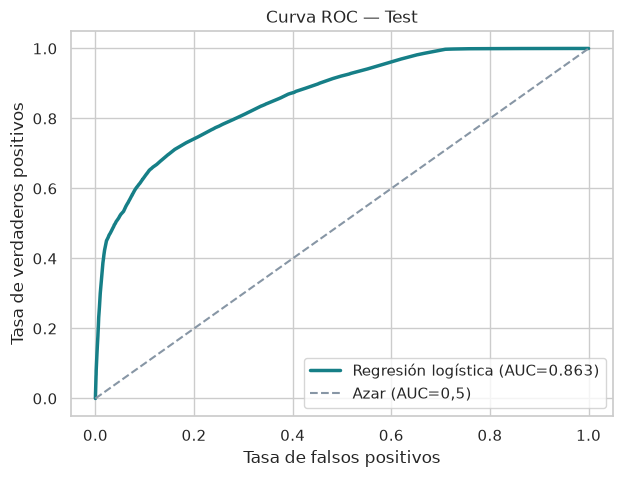

Un AUC cercano a 0,5 indica poca discriminación; un AUC cercano a 1 indica buena capacidad de separar las clases.

In [10]:
probabilidades_test = ejecucion['pipeline'].predict_proba(ejecucion['X_test'])[:, 1]
fpr, tpr, _ = roc_curve(ejecucion['y_test'], probabilidades_test)
auc_test = roc_auc_score(ejecucion['y_test'], probabilidades_test)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#167f87', linewidth=2.5, label=f'Regresión logística (AUC={auc_test:.3f})')
plt.plot([0, 1], [0, 1], '--', color='#8796a5', label='Azar (AUC=0,5)')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC — Test')
plt.legend()
plt.show()
display(Markdown('Un AUC cercano a 0,5 indica poca discriminación; un AUC cercano a 1 indica buena capacidad de separar las clases.'))

### 14. Comparación Train vs Test

In [11]:
comparacion_metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    'Train': [resumen['metricas']['train'][clave] for clave in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']],
    'Test': [resumen['metricas']['test'][clave] for clave in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']],
})
display(comparacion_metricas.style.format({'Train': '{:.4f}', 'Test': '{:.4f}'}))
display(Markdown(resumen['interpretacion_primera_iteracion']))

,Métrica,Train,Test
0,Accuracy,0.8031,0.8034
1,Precision,0.8140,0.8144
2,Recall,0.9417,0.9416
3,F1,0.8732,0.8734
4,ROC-AUC,0.8623,0.8625


Las métricas de train y test son cercanas, lo que indica un comportamiento consistente sin una señal importante de sobreajuste.

### 15. Interpretación del modelo

Un coeficiente positivo aumenta el log-odds de pertenecer a la clase con Internet; uno negativo lo reduce. Un Odds Ratio mayor que 1 representa mayores odds y uno menor que 1, menores odds frente a la categoría de referencia o por una unidad adicional. Estas son asociaciones condicionadas por el modelo y **no demuestran causalidad**.

,descripcion,coeficiente,odds_ratio
0,19.4. Su hogar tiene: Teléfono celular: No (referencia: Sí),-3.8395,0.0215
1,"19.3. Su hogar tiene: Computadora, laptop o tablet: No (referencia: Sí)",-2.3819,0.0924
2,Área Urbana - Rural: Rural (referencia: Urbana),-1.0132,0.3631
3,1. La vivienda es: (Tipo de vivienda): Departamento (referencia: Casa),0.6642,1.9429
4,9. De donde proviene la energía eléctrica que usan en la vivienda: No tiene (referencia: Servicio público de energía eléctrica),-0.3799,0.6839
5,9. De donde proviene la energía eléctrica que usan en la vivienda: Panel solar (referencia: Servicio público de energía eléctrica),-0.3670,0.6928
6,1. La vivienda es: (Tipo de vivienda): Vivienda improvisada o vivienda móvil (referencia: Casa),0.3130,1.3675
7,1. La vivienda es: (Tipo de vivienda): Cuarto(s) o habitación(es) suelta(s) (referencia: Casa),0.2104,1.2341
8,"1. La vivienda es: (Tipo de vivienda): Choza, pahuichi (referencia: Casa)",0.1553,1.1680
9,9. De donde proviene la energía eléctrica que usan en la vivienda: Motor propio (Generador) (referencia: Servicio público de energía eléctrica),0.1430,1.1537


/tmp/ipykernel_2637/1998144833.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


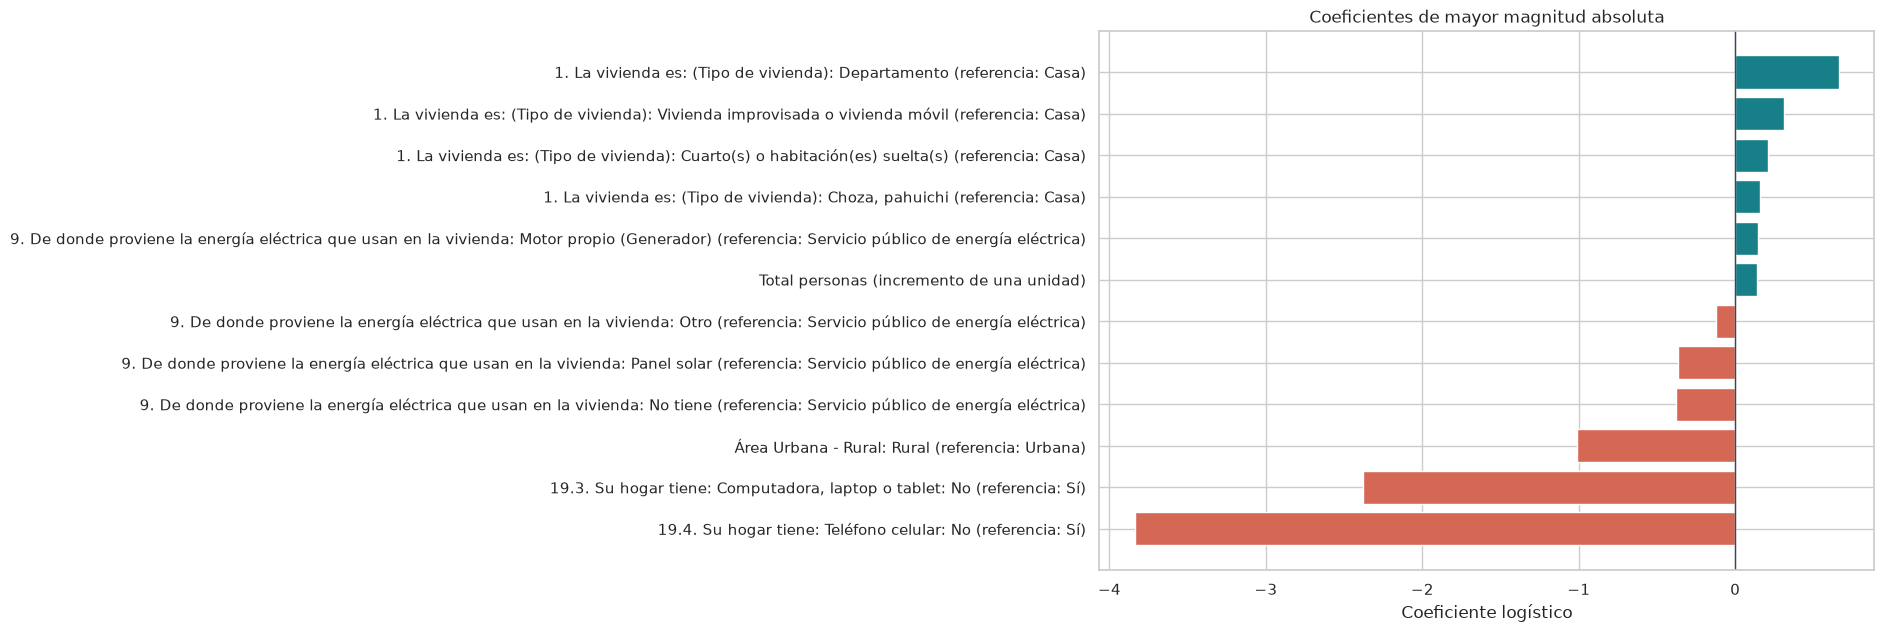

In [12]:
coeficientes = ejecucion['coeficientes'].copy()
display(coeficientes[['descripcion', 'coeficiente', 'odds_ratio']].style.format({'coeficiente': '{:.4f}', 'odds_ratio': '{:.4f}'}))

grafico_coef = coeficientes.nlargest(12, 'impacto_absoluto').sort_values('coeficiente')
plt.figure(figsize=(10, 7))
colores = np.where(grafico_coef['coeficiente'] >= 0, '#167f87', '#d56855')
plt.barh(grafico_coef['descripcion'], grafico_coef['coeficiente'], color=colores)
plt.axvline(0, color='#34495e', linewidth=1)
plt.xlabel('Coeficiente logístico')
plt.ylabel('')
plt.title('Coeficientes de mayor magnitud absoluta')
plt.tight_layout()
plt.show()

### 16. Statsmodels

Se ajusta `statsmodels.api.Logit` con constante sobre las variables procesadas de entrenamiento. Los p-values y los intervalos de confianza complementan la evaluación predictiva; no se seleccionan variables únicamente por su p-value.

In [13]:
display(ejecucion['statsmodels_result'].summary())
relevantes = coeficientes.loc[coeficientes['p_value'] < 0.05, ['descripcion', 'coeficiente_statsmodels', 'p_value', 'ci_95_inferior', 'ci_95_superior']]
display(Markdown(f"**Términos con p-value < 0,05:** {len(relevantes)} de {len(coeficientes)}."))
display(relevantes.style.format({'coeficiente_statsmodels': '{:.4f}', 'p_value': '{:.3g}', 'ci_95_inferior': '{:.4f}', 'ci_95_superior': '{:.4f}'}))

<class 'statsmodels.iolib.summary.Summary'>
"""
                             Logit Regression Results                            
=================================================================================
Dep. Variable:     TIENE_ACCESO_INTERNET   No. Observations:               831472
Model:                             Logit   Df Residuals:                   831457
Method:                              MLE   Df Model:                           14
Date:                   Sun, 20 Sep 2026   Pseudo R-squ.:                  0.3506
Time:                           16:00:43   Log-Likelihood:            -3.2011e+05
converged:                          True   LL-Null:                   -4.9297e+05
Covariance Type:               nonrobust   LLR p-value:                     0.000
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           3.2253      0.014    223.322      0.000       3.197       3.254
categoricas__urbrur_2          -1.0144      0.007   -151.864      0.000      -1.028      -1.001
categoricas__v01_tipoviv_2      0.1588      0.017      9.134      0.000       0.125       0.193
categoricas__v01_tipoviv_3      0.6734      0.019     34.812      0.000       0.635       0.711
categoricas__v01_tipoviv_4      0.2204      0.013     17.149      0.000       0.195       0.246
categoricas__v01_tipoviv_5      0.3364      0.033     10.225      0.000       0.272       0.401
categoricas__v01_tipoviv_6      0.0634      0.056      1.128      0.259      -0.047       0.174
categoricas__v09_energia_2      0.1442      0.040      3.645      0.000       0.067       0.222
categoricas__v09_energia_3     -0.3516      0.028    -12.592      0.000      -0.406      -0.297
categoricas__v09_energia_4     -0.1641      0.037     -4.411      0.000      -0.237      -0.091
categoricas__v09_energia_5     -0.3826      0.009    -41.139      0.000      -0.401      -0.364
categoricas__v19c_compu_2      -2.3866      0.012   -198.118      0.000      -2.410      -2.363
categoricas__v19d_celular_2    -3.8297      0.017   -219.100      0.000      -3.864      -3.795
numericas__v13_habitac          0.0234      0.003      9.284      0.000       0.018       0.028
numericas__tot_pers             0.1381      0.002     73.738      0.000       0.134       0.142
===============================================================================================
"""

**Términos con p-value < 0,05:** 13 de 14.

,descripcion,coeficiente_statsmodels,p_value,ci_95_inferior,ci_95_superior
0,19.4. Su hogar tiene: Teléfono celular: No (referencia: Sí),-3.8297,0,-3.8639,-3.7954
1,"19.3. Su hogar tiene: Computadora, laptop o tablet: No (referencia: Sí)",-2.3866,0,-2.4102,-2.3630
2,Área Urbana - Rural: Rural (referencia: Urbana),-1.0144,0,-1.0275,-1.0013
3,1. La vivienda es: (Tipo de vivienda): Departamento (referencia: Casa),0.6734,1.61e-265,0.6355,0.7113
4,9. De donde proviene la energía eléctrica que usan en la vivienda: No tiene (referencia: Servicio público de energía eléctrica),-0.3826,0,-0.4008,-0.3643
5,9. De donde proviene la energía eléctrica que usan en la vivienda: Panel solar (referencia: Servicio público de energía eléctrica),-0.3516,2.34e-36,-0.4064,-0.2969
6,1. La vivienda es: (Tipo de vivienda): Vivienda improvisada o vivienda móvil (referencia: Casa),0.3364,1.54e-24,0.2719,0.4008
7,1. La vivienda es: (Tipo de vivienda): Cuarto(s) o habitación(es) suelta(s) (referencia: Casa),0.2204,6.42e-66,0.1952,0.2456
8,"1. La vivienda es: (Tipo de vivienda): Choza, pahuichi (referencia: Casa)",0.1588,6.61e-20,0.1247,0.1929
9,9. De donde proviene la energía eléctrica que usan en la vivienda: Motor propio (Generador) (referencia: Servicio público de energía eléctrica),0.1442,0.000268,0.0666,0.2217


### 17. Baseline

In [14]:
pd.DataFrame({
    'Modelo': ['Baseline: siempre clase mayoritaria', 'Regresión logística'],
    'Accuracy test': [resumen['baseline']['accuracy_test'], resumen['metricas']['test']['accuracy']],
}).style.format({'Accuracy test': '{:.4f}'})

,Modelo,Accuracy test
0,Baseline: siempre clase mayoritaria,0.7201
1,Regresión logística,0.8034


La comparación con el baseline es necesaria porque la clase positiva es mayoritaria. Una accuracy alta por sí sola no garantiza que el modelo aporte capacidad predictiva.

### 18. Umbral de clasificación

El resultado principal conserva el umbral por defecto de `0,5`. No se presenta un umbral alternativo porque esta primera iteración no define todavía un costo operativo distinto para falsos positivos y falsos negativos. Cualquier cambio futuro deberá justificarse mediante el equilibrio entre precision, recall y el objetivo de uso.

## Resultados de la primera iteración

In [15]:
mtrain = resumen['metricas']['train']
mtest = resumen['metricas']['test']
variables_texto = ', '.join(MODEL_FEATURES)
display(Markdown(f'''
1. **Métrica:** acceso a Internet fijo y/o móvil.
2. **Variable que representa la métrica:** `{TARGET_SOURCE}`.
3. **Target:** `{TARGET}`; 1=tiene acceso y 0=no tiene acceso.
4. **Variables explicativas:** {variables_texto}.
5. **Train:** {resumen['particion']['train']:,} registros.
6. **Test:** {resumen['particion']['test']:,} registros.
7. **Train:** Accuracy={mtrain['accuracy']:.4f}, Precision={mtrain['precision']:.4f}, Recall={mtrain['recall']:.4f}, F1={mtrain['f1']:.4f}, ROC-AUC={mtrain['roc_auc']:.4f}.
8. **Test:** Accuracy={mtest['accuracy']:.4f}, Precision={mtest['precision']:.4f}, Recall={mtest['recall']:.4f}, F1={mtest['f1']:.4f}, ROC-AUC={mtest['roc_auc']:.4f}.
9. **Conclusión inicial:** {resumen['interpretacion_primera_iteracion']} El desempeño supera el baseline de accuracy {resumen['baseline']['accuracy_test']:.4f}.
'''))


1. **Métrica:** acceso a Internet fijo y/o móvil.
2. **Variable que representa la métrica:** `v19e_f`.
3. **Target:** `TIENE_ACCESO_INTERNET`; 1=tiene acceso y 0=no tiene acceso.
4. **Variables explicativas:** urbrur, v01_tipoviv, v09_energia, v19c_compu, v19d_celular, v13_habitac, tot_pers.
5. **Train:** 831,472 registros.
6. **Test:** 207,869 registros.
7. **Train:** Accuracy=0.8031, Precision=0.8140, Recall=0.9417, F1=0.8732, ROC-AUC=0.8623.
8. **Test:** Accuracy=0.8034, Precision=0.8144, Recall=0.9416, F1=0.8734, ROC-AUC=0.8625.
9. **Conclusión inicial:** Las métricas de train y test son cercanas, lo que indica un comportamiento consistente sin una señal importante de sobreajuste. El desempeño supera el baseline de accuracy 0.7201.


### 20. Conclusiones

In [16]:
mayor_positiva = coeficientes.loc[coeficientes['coeficiente'].idxmax()]
mayor_negativa = coeficientes.loc[coeficientes['coeficiente'].idxmin()]
ganancia_baseline = mtest['accuracy'] - resumen['baseline']['accuracy_test']
display(Markdown(f'''
1. El modelo alcanza ROC-AUC **{mtest['roc_auc']:.4f}** y F1 **{mtest['f1']:.4f}** en test; discrimina mejor que el azar y mantiene un desempeño útil en esta primera iteración.
2. Para la clase positiva —viviendas con Internet— logra recall **{mtest['recall']:.4f}** y precision **{mtest['precision']:.4f}**. La matriz muestra {fn:,} falsos negativos y {fp:,} falsos positivos.
3. La mayor asociación positiva observada es **{mayor_positiva['descripcion']}** (OR={mayor_positiva['odds_ratio']:.3f}); la mayor asociación negativa es **{mayor_negativa['descripcion']}** (OR={mayor_negativa['odds_ratio']:.3f}). Son asociaciones, no efectos causales.
4. La accuracy de test supera al baseline mayoritario en **{ganancia_baseline:.4f}** puntos y las métricas de train y test son cercanas, sin señal importante de sobreajuste.
5. Las limitaciones incluyen desbalance de clases, predictores censales acotados y un umbral todavía no vinculado a costos de decisión. Un siguiente paso es validar estabilidad por territorio y estudiar umbrales según el uso del modelo.
'''))


1. El modelo alcanza ROC-AUC **0.8625** y F1 **0.8734** en test; discrimina mejor que el azar y mantiene un desempeño útil en esta primera iteración.
2. Para la clase positiva —viviendas con Internet— logra recall **0.9416** y precision **0.8144**. La matriz muestra 8,744 falsos negativos y 32,114 falsos positivos.
3. La mayor asociación positiva observada es **1. La vivienda es: (Tipo de vivienda): Departamento (referencia: Casa)** (OR=1.943); la mayor asociación negativa es **19.4. Su hogar tiene: Teléfono celular: No (referencia: Sí)** (OR=0.022). Son asociaciones, no efectos causales.
4. La accuracy de test supera al baseline mayoritario en **0.0834** puntos y las métricas de train y test son cercanas, sin señal importante de sobreajuste.
5. Las limitaciones incluyen desbalance de clases, predictores censales acotados y un umbral todavía no vinculado a costos de decisión. Un siguiente paso es validar estabilidad por territorio y estudiar umbrales según el uso del modelo.
